# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 58    |  |
| :-------------|:-------------|
| Oscar Wesdorp| 6578365|
|Luuk van Dijk| 6518702|
|Jan van de Poll| 6527590|
|Jochem van den Boomen| 6527620|

In [37]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Oscar Wesdorp']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Tijdstip |
| Mijlpaal 2 | Tijdstip |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |

## Opdracht 2: Import libs.

In [38]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep
<img src="fotocalibratie.jpg" width="400">


Fit parameter:
a = 0.03404387545833065


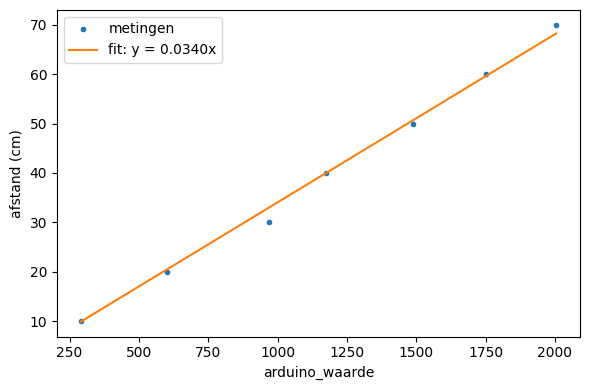

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
arduino_waarde = np.array([970, 290, 600, 1175, 1490, 1750, 2005])
afstand = np.array([30, 10, 20, 40, 50, 60, 70])

def lineair_0(x, a):
    return a * x

params, cov = curve_fit(lineair_0, arduino_waarde, afstand)
a = params[0]
print("Fit parameter:")
print(f"a = {a}")

plt.figure(figsize=(6,4))
plt.plot(arduino_waarde, afstand, '.', label='metingen')

x_line = np.linspace(min(arduino_waarde), max(arduino_waarde), 200)
y_line = lineair_0(x_line, a)
plt.plot(x_line, y_line, '-', label=f'fit: y = {a:.4f}x')

plt.xlabel('arduino_waarde')
plt.ylabel('afstand (cm)')
plt.legend()
plt.tight_layout()
plt.show()


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  40   0  30  43
1   0  30   0  20  43
2   0  10   0  20  51
3  40   0  30   0  42
4  30   0  20   0  42


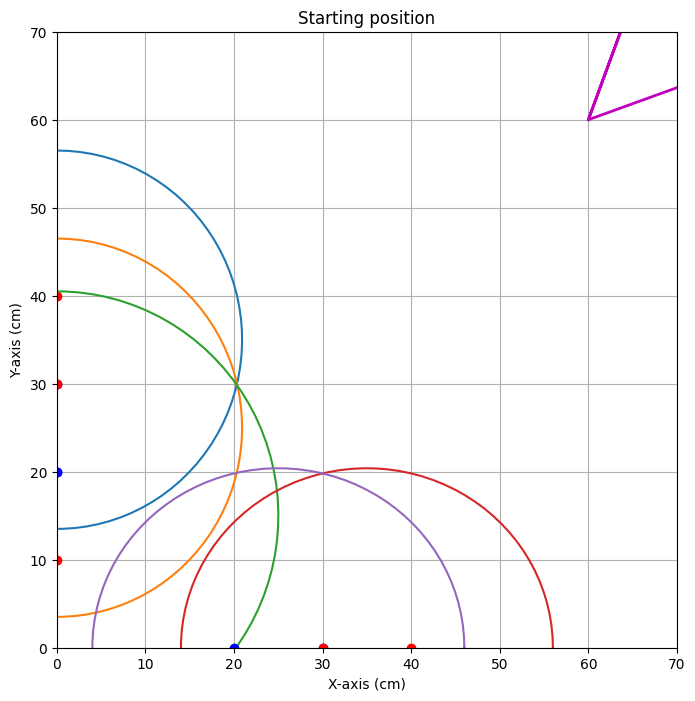


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=100.766


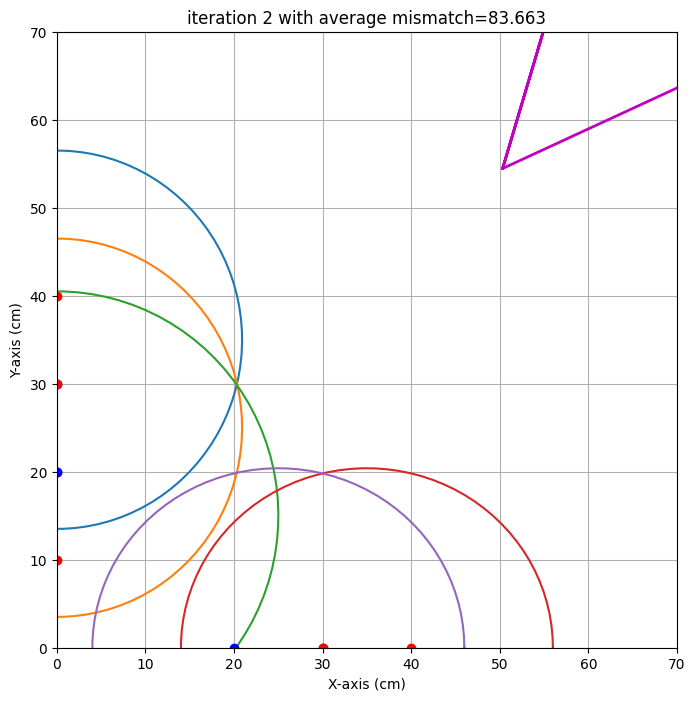

end iteration 2 with average mismatch=83.663


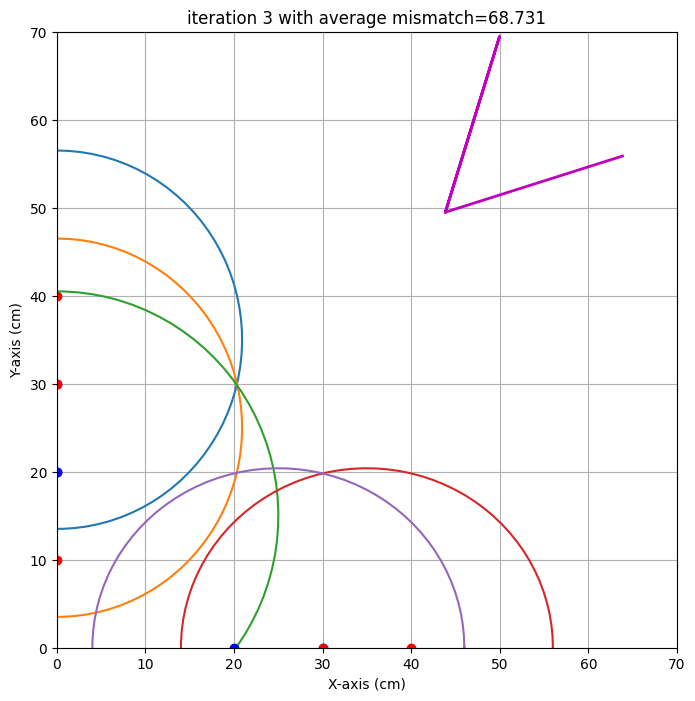

end iteration 3 with average mismatch=68.731


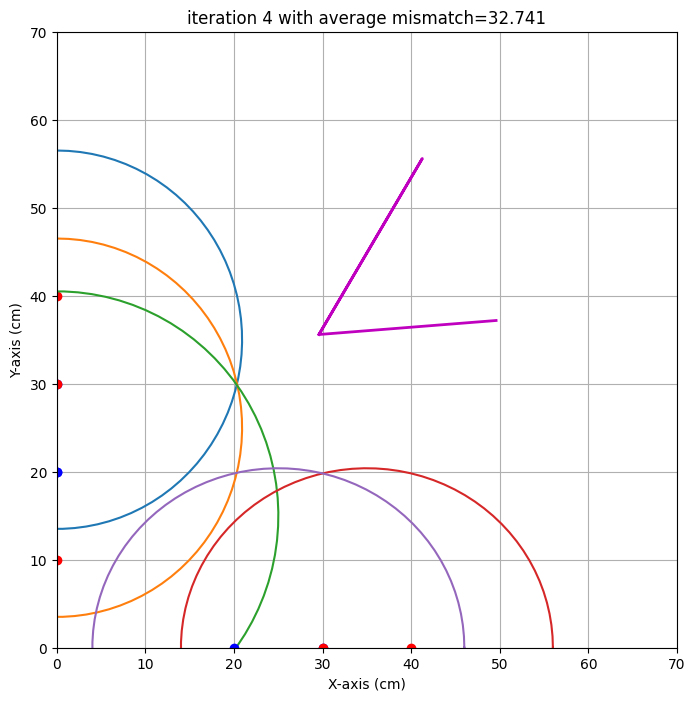

end iteration 4 with average mismatch=32.741


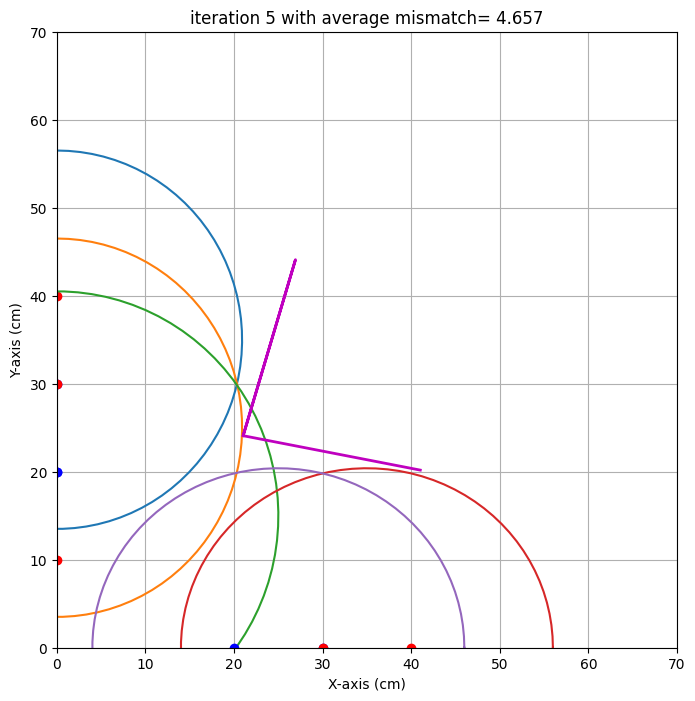

end iteration 5 with average mismatch= 4.657


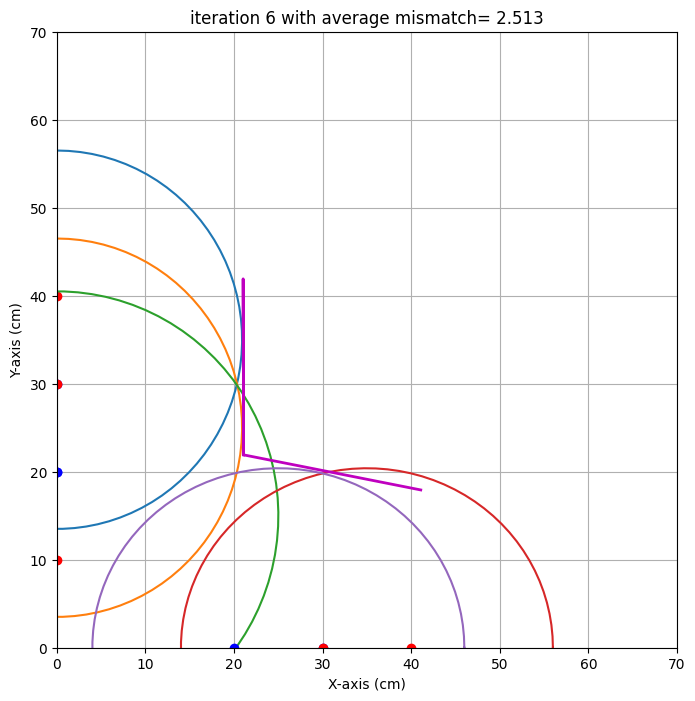

end iteration 6 with average mismatch= 2.513


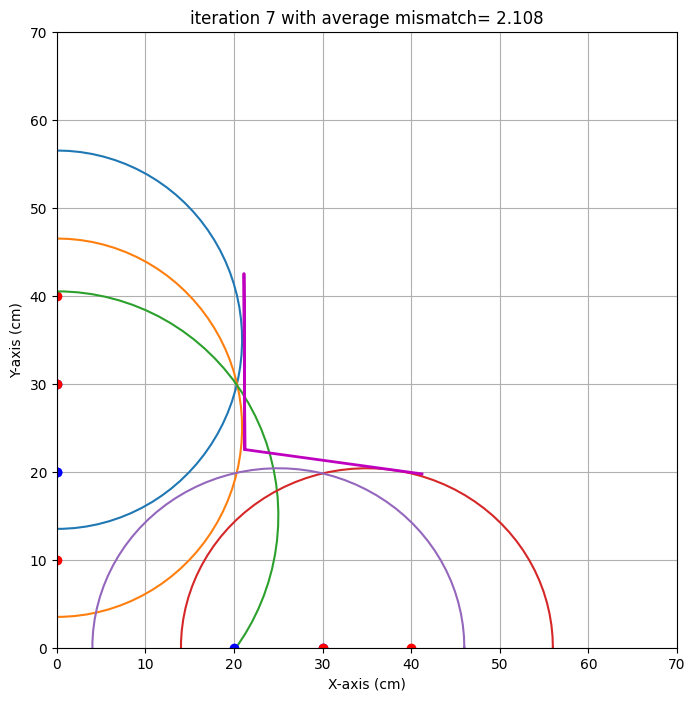

end iteration 7 with average mismatch= 2.108
end iteration 8 with average mismatch= 2.087


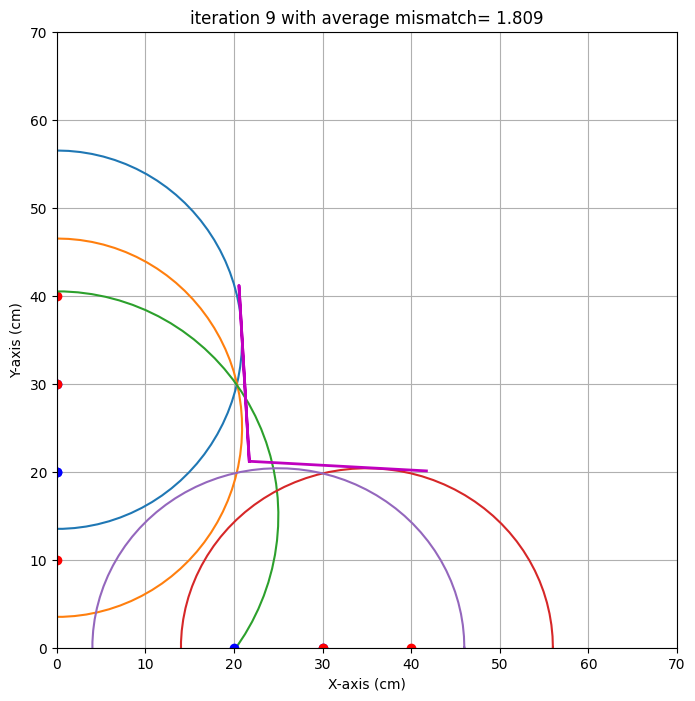

end iteration 9 with average mismatch= 1.809


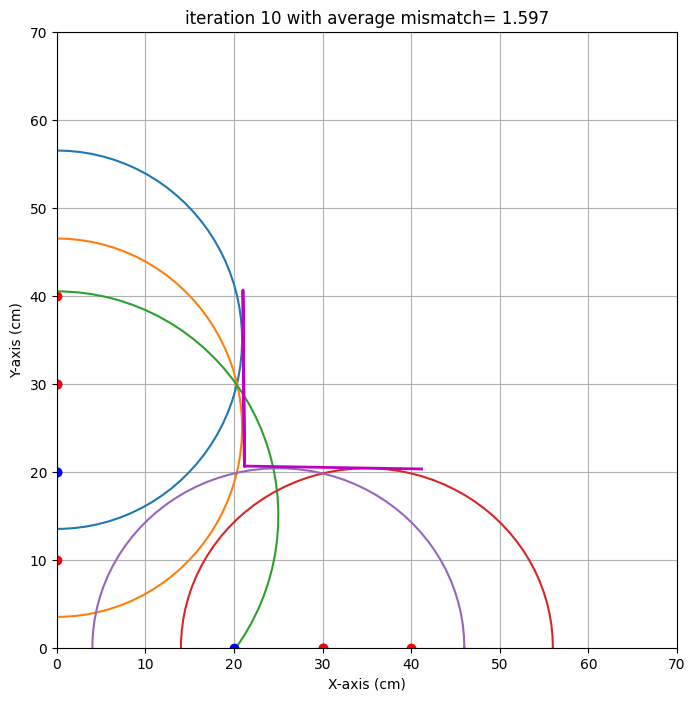

end iteration 10 with average mismatch= 1.597
end iteration 11 with average mismatch= 1.579
end iteration 12 with average mismatch= 1.578
end iteration 13 with average mismatch= 1.578
end iteration 14 with average mismatch= 1.577
end iteration 15 with average mismatch= 1.577
end iteration 16 with average mismatch= 1.553
end iteration 17 with average mismatch= 1.553
end iteration 18 with average mismatch= 1.553
end iteration 19 with average mismatch= 1.553
end iteration 20 with average mismatch= 1.553
end iteration 21 with average mismatch= 1.553
end iteration 22 with average mismatch= 1.553
end iteration 23 with average mismatch= 1.553
end iteration 24 with average mismatch= 1.553
end iteration 25 with average mismatch= 1.553
end iteration 26 with average mismatch= 1.456
end iteration 27 with average mismatch= 1.444
end iteration 28 with average mismatch= 1.441
end iteration 29 with average mismatch= 1.440
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

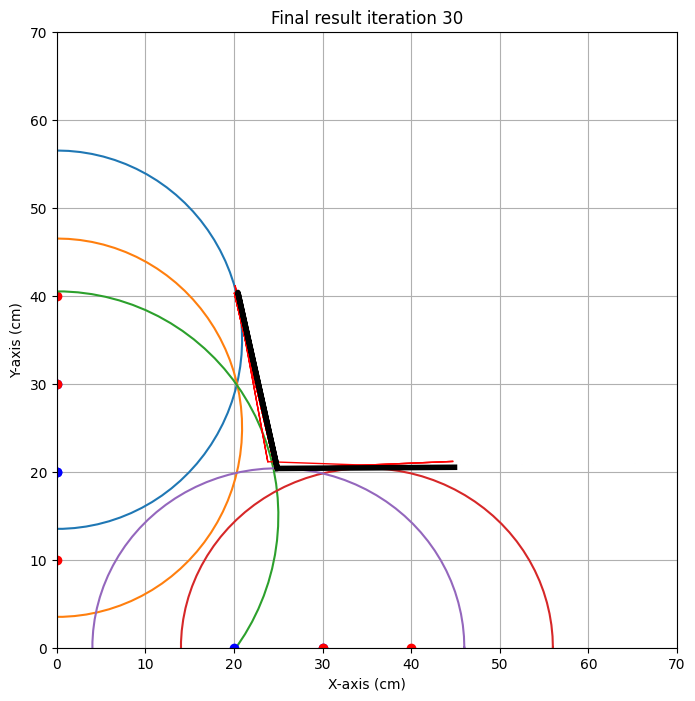

In [40]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.


dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,43],
    [0,30,0,20,43],
    [0,10,0,20,51],
    [40,0,30,0,42],
    [30,0,20,0,42],
    #[10,0,20,0,85],
    #[10,0,0,10,104]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [41]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 24.9 cm met een standaardafwijking van 0.0 cm 
y0: 20.4 cm met een standaardafwijking van 0.0 cm 
alpha: 0.4 graden met een standaardafwijking van 0.0 graad 
beta: -12.6 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Luuk van Dijk]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="algoritmeluuk.jpg" width="400">

#### algoritme [Oscar Wesdorp]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="algoritmeoscar.jpg" width="400">

#### algoritme [Jochem van den Boomen]
Voeg een foto in van het algoritme van het derde groepslid
<img src="algoritmejochem.jpg" width="400">

In [42]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [43]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':45,  #zelf aanvullen,
           'y0':50,#zelf aanvullen,
           'alpha' :-5, #zelf aanvullen,
           'beta' :5, #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'luuk' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    [20,0,70,0,110],
    [35,0,55,0,100],
    [0,50,0,60,86],
    [0,50,0,70,86],
    ]),
       'Oscar' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    [20,0,30,0,111],
    [30,0,40,0,102],
    [40,0,50,0,99],
    [50,0,60,0,98],
    [0,30,0,40,114],
    [0,40,0,50,89],
   [ 0,50,0,60,86]]),
       'Jochem' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    #eerste meting reeel
    [55,0,65,0,97],
    [50,0,60,0,97],
    [0,55,0,65,86],
    [0,50,0,60,87]])
      }

## Opdracht 7: Evaluatie.

luuk
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0  20   0  70   0  110
1  35   0  55   0  100
2   0  50   0  60   86
3   0  50   0  70   86


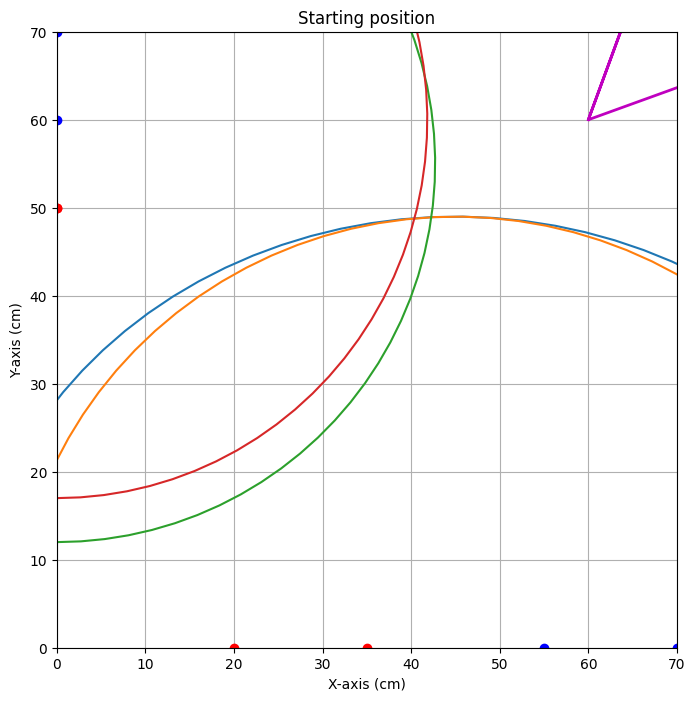


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=35.058


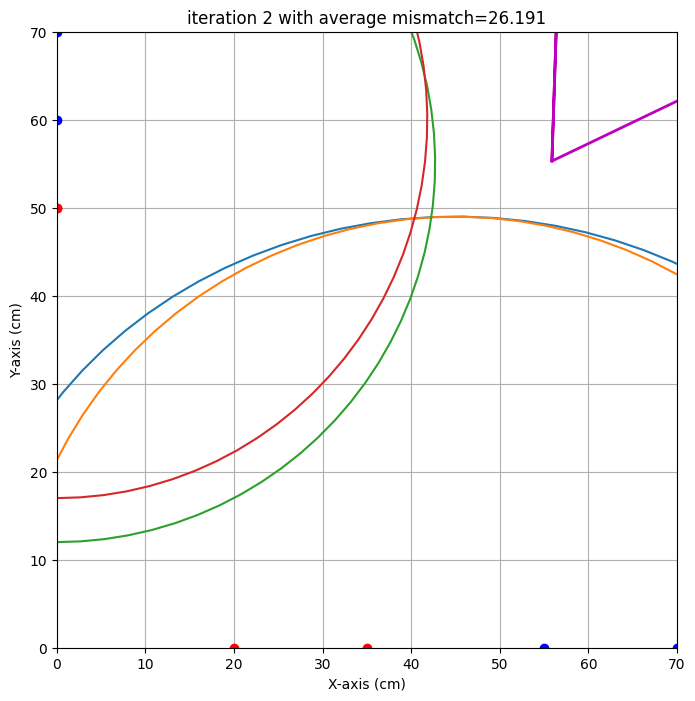

end iteration 2 with average mismatch=26.191


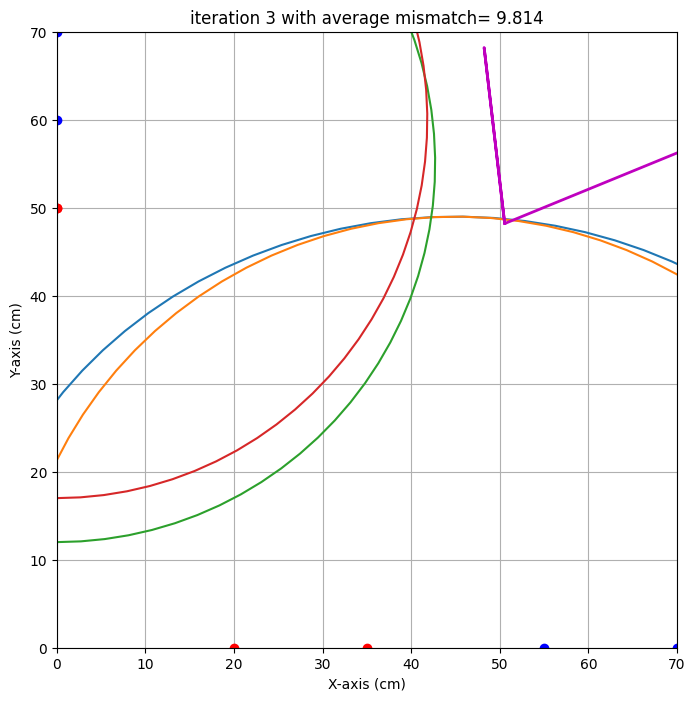

end iteration 3 with average mismatch= 9.814


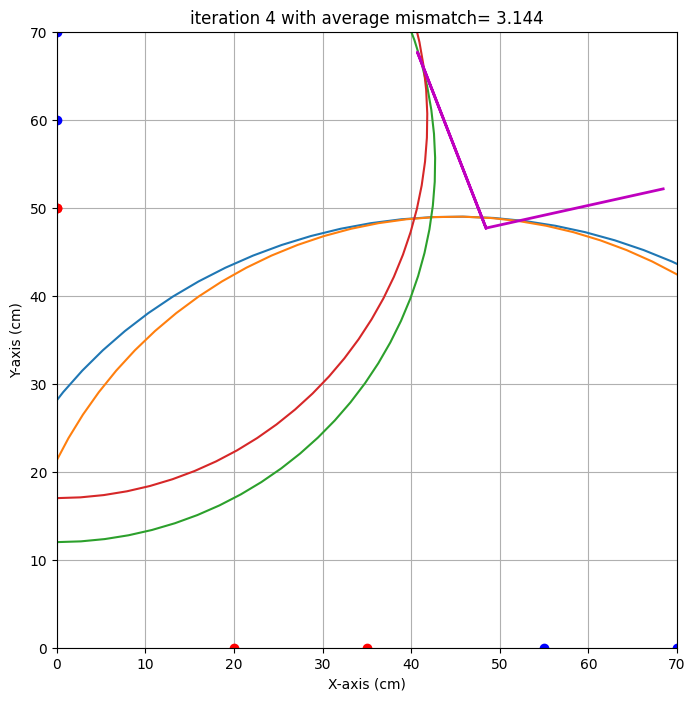

end iteration 4 with average mismatch= 3.144


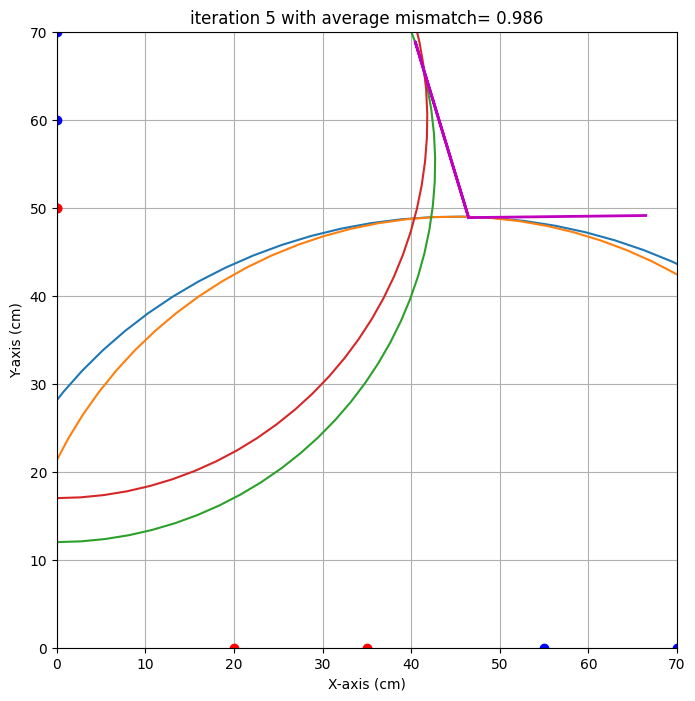

end iteration 5 with average mismatch= 0.986


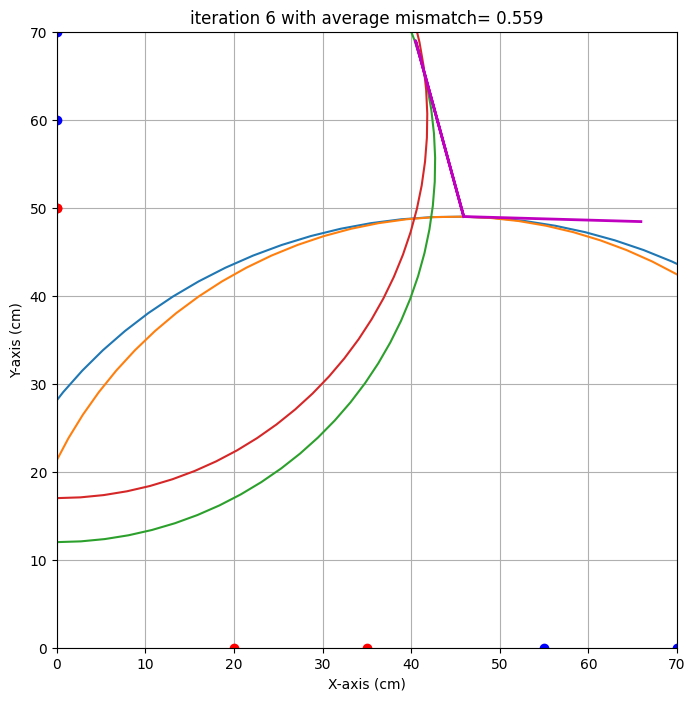

end iteration 6 with average mismatch= 0.559
end iteration 7 with average mismatch= 0.525


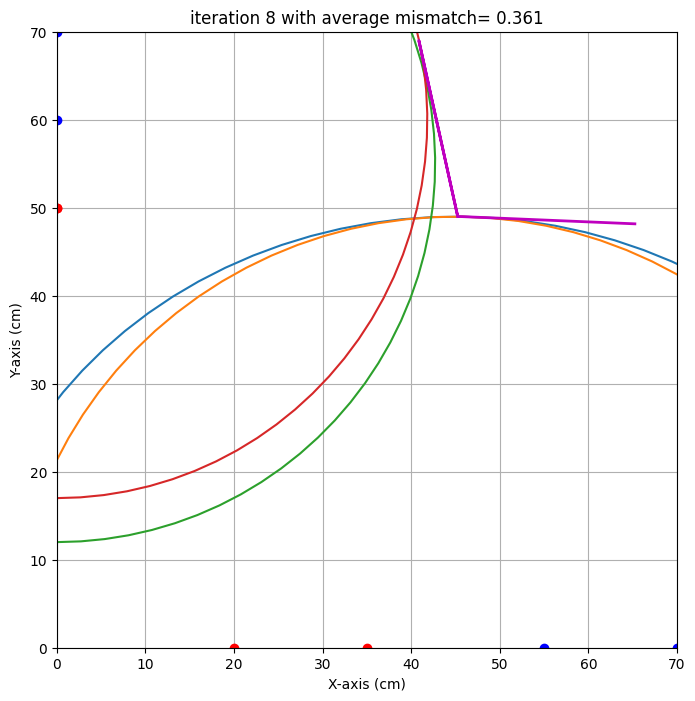

end iteration 8 with average mismatch= 0.361


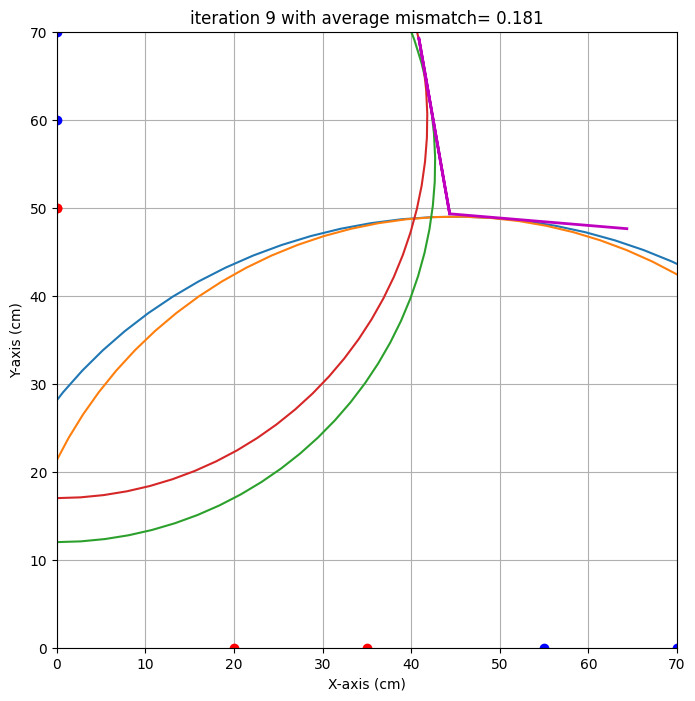

end iteration 9 with average mismatch= 0.181


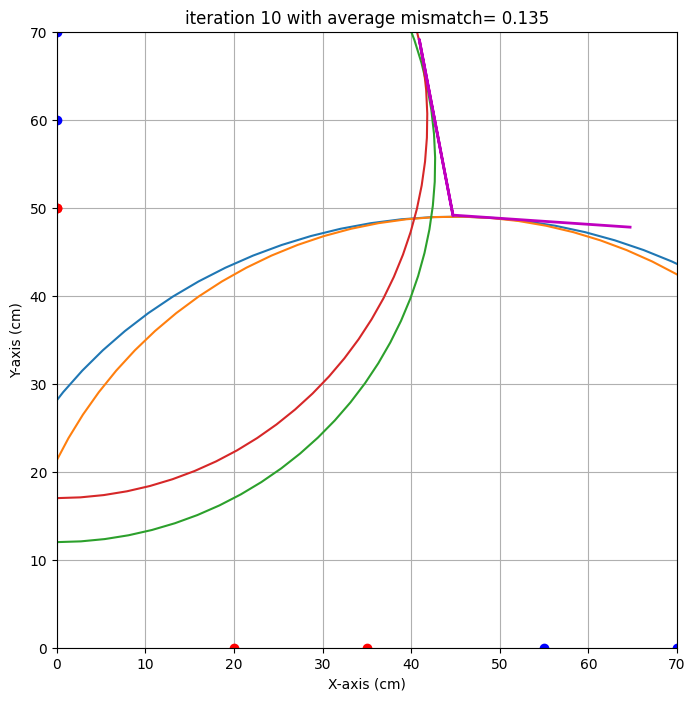

end iteration 10 with average mismatch= 0.135


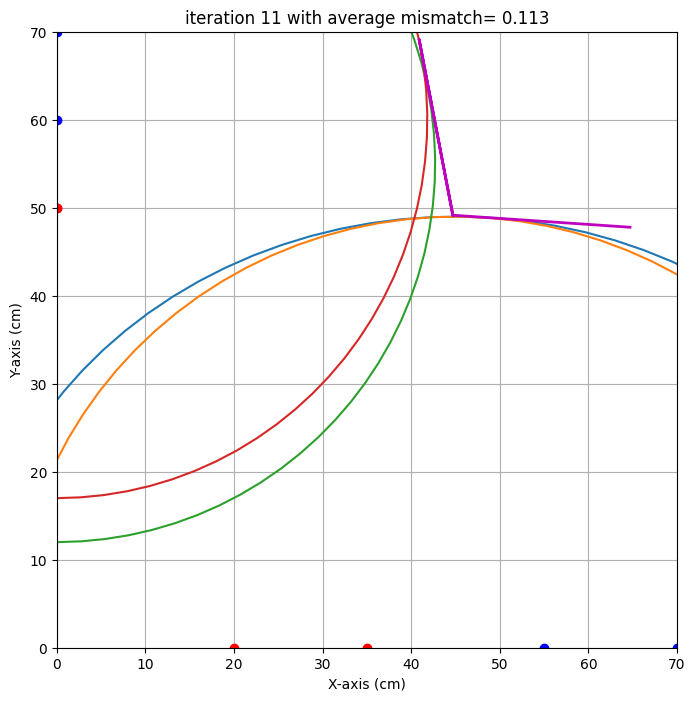

end iteration 11 with average mismatch= 0.113
end iteration 12 with average mismatch= 0.110
end iteration 13 with average mismatch= 0.108
end iteration 14 with average mismatch= 0.108
end iteration 15 with average mismatch= 0.107
end iteration 16 with average mismatch= 0.107
end iteration 17 with average mismatch= 0.107
end iteration 18 with average mismatch= 0.107
end iteration 19 with average mismatch= 0.107
end iteration 20 with average mismatch= 0.107
end iteration 21 with average mismatch= 0.107
end iteration 22 with average mismatch= 0.107
end iteration 23 with average mismatch= 0.107
end iteration 24 with average mismatch= 0.107
end iteration 25 with average mismatch= 0.107
end iteration 26 with average mismatch= 0.107
end iteration 27 with average mismatch= 0.107
end iteration 28 with average mismatch= 0.107
end iteration 29 with average mismatch= 0.107
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little lon

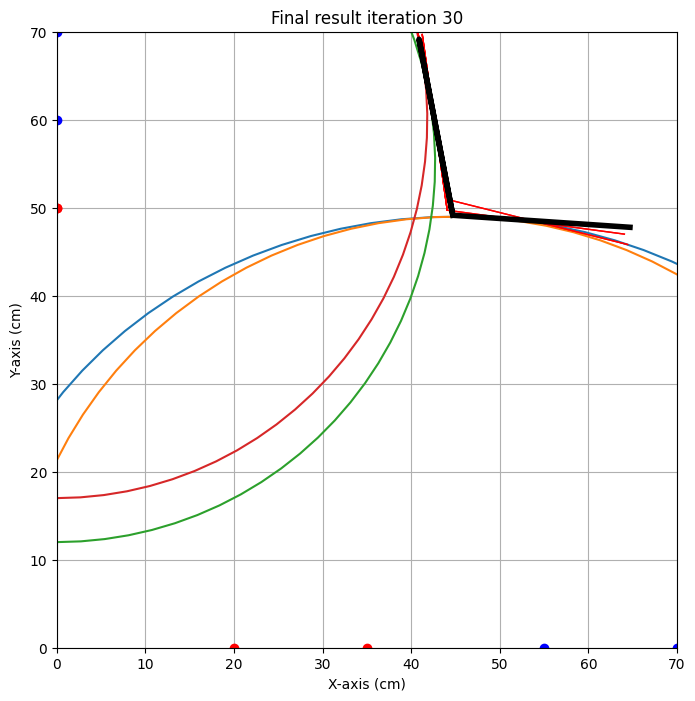

{'alpha': np.float64(-3.9124976420448374), 'alpha_eps': np.float64(10.216189395586758), 'beta': np.float64(-10.802207192824556), 'beta_eps': np.float64(2.7614549220473688), 'x0': np.float64(44.70019101521657), 'x0_eps': np.float64(0.630681590555902), 'y0': np.float64(49.14436008930579), 'y0_eps': np.float64(1.7091803739157285)}
Oscar
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0  20   0  30   0  111
1  30   0  40   0  102
2  40   0  50   0   99
3  50   0  60   0   98
4   0  30   0  40  114
5   0  40   0  50   89
6   0  50   0  60   86


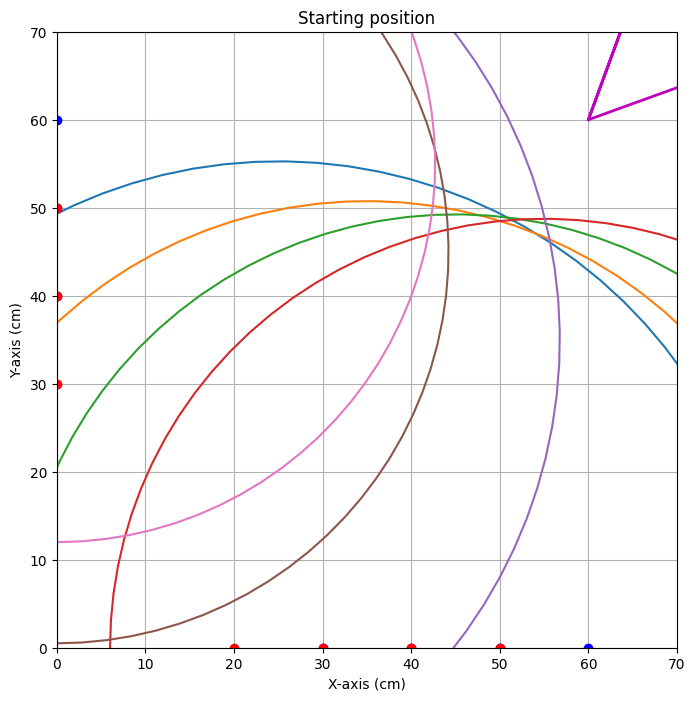


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=33.981


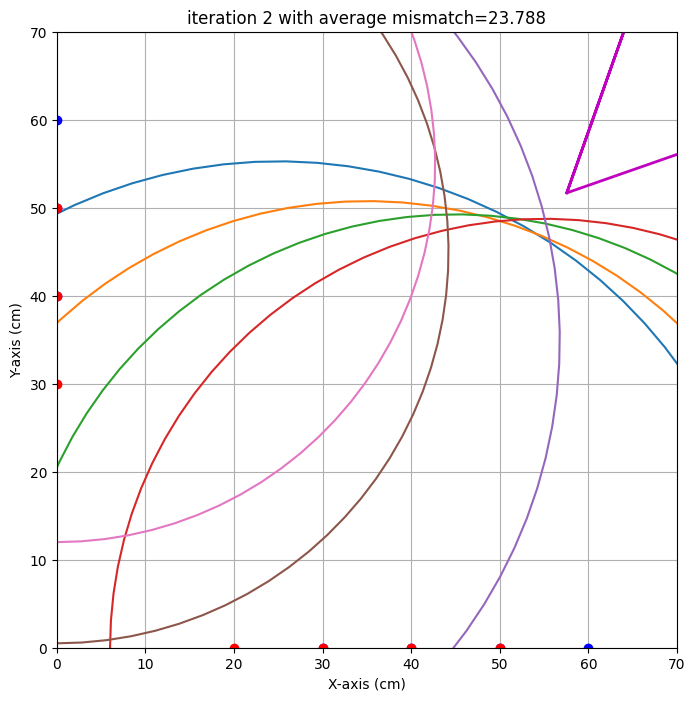

end iteration 2 with average mismatch=23.788


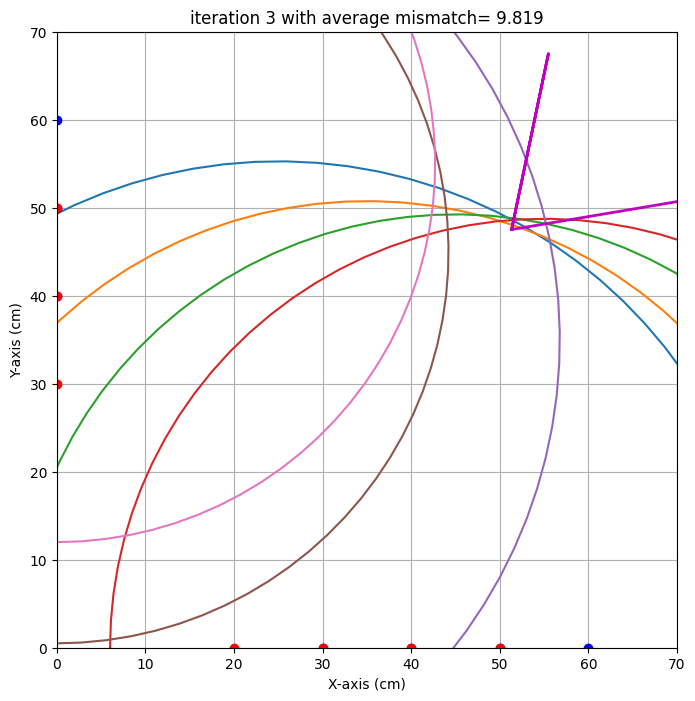

end iteration 3 with average mismatch= 9.819


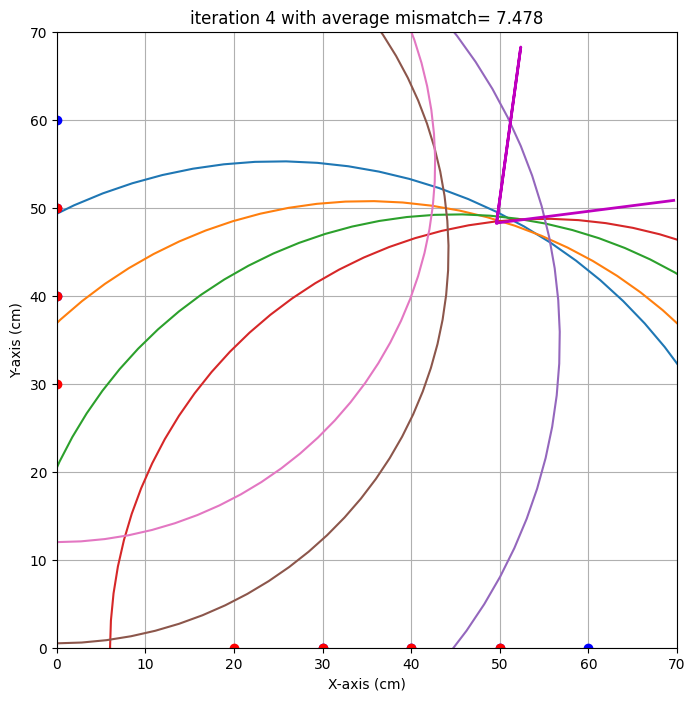

end iteration 4 with average mismatch= 7.478


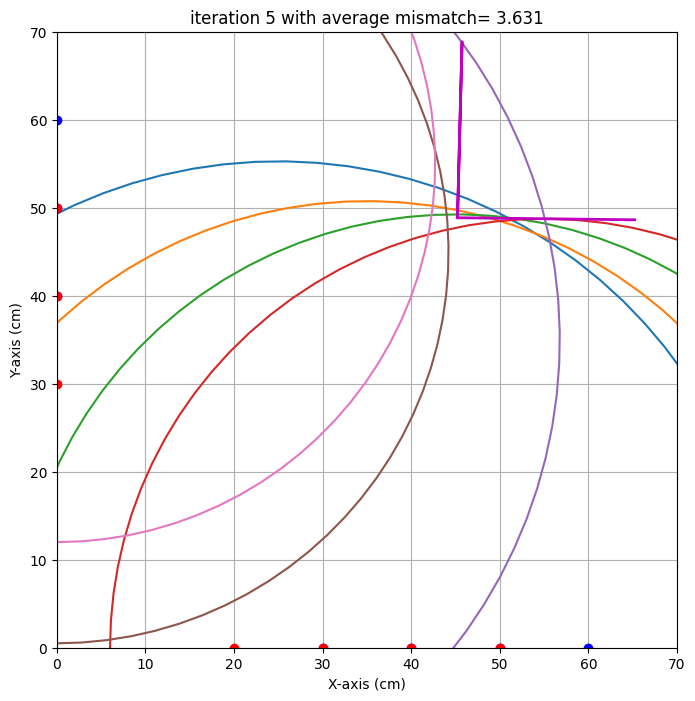

end iteration 5 with average mismatch= 3.631


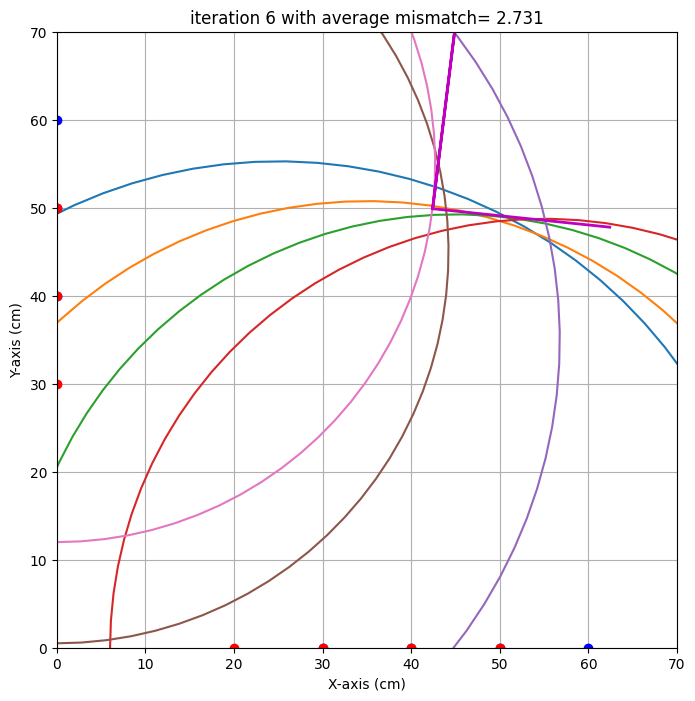

end iteration 6 with average mismatch= 2.731
end iteration 7 with average mismatch= 2.620
end iteration 8 with average mismatch= 2.520
end iteration 9 with average mismatch= 2.520
end iteration 10 with average mismatch= 2.520
end iteration 11 with average mismatch= 2.520
end iteration 12 with average mismatch= 2.520
end iteration 13 with average mismatch= 2.520
end iteration 14 with average mismatch= 2.520
end iteration 15 with average mismatch= 2.520
end iteration 16 with average mismatch= 2.520
end iteration 17 with average mismatch= 2.520
end iteration 18 with average mismatch= 2.520
end iteration 19 with average mismatch= 2.520
end iteration 20 with average mismatch= 2.520
end iteration 21 with average mismatch= 2.520
end iteration 22 with average mismatch= 2.520
end iteration 23 with average mismatch= 2.520
end iteration 24 with average mismatch= 2.520
end iteration 25 with average mismatch= 2.520
end iteration 26 with average mismatch= 2.520
end iteration 27 with average mismatch

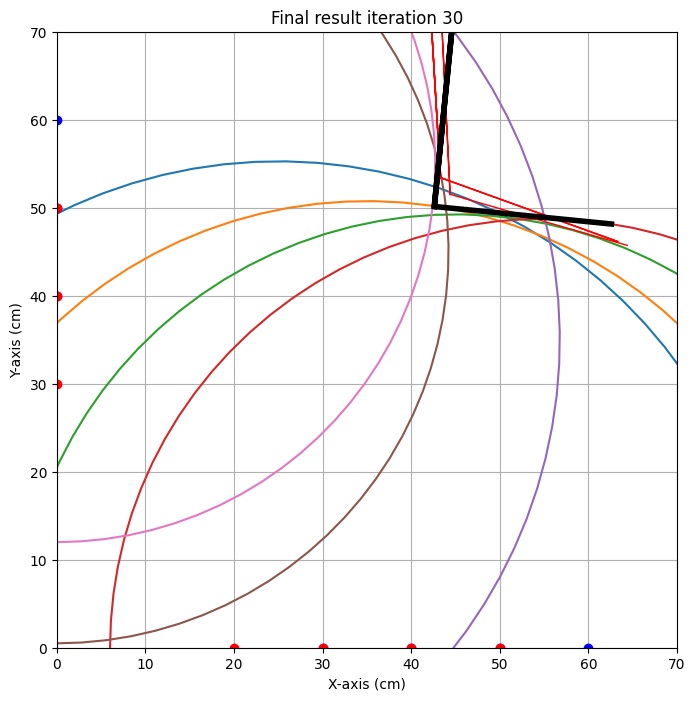

{'alpha': np.float64(-5.679932304121457), 'alpha_eps': np.float64(14.262041684362632), 'beta': np.float64(5.659996617015693), 'beta_eps': np.float64(9.036177148830765), 'x0': np.float64(42.609279452127566), 'x0_eps': np.float64(1.784719838740088), 'y0': np.float64(50.13928823227833), 'y0_eps': np.float64(3.2764755256667755)}
Jochem
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  55   0  65   0  97
1  50   0  60   0  97
2   0  55   0  65  86
3   0  50   0  60  87


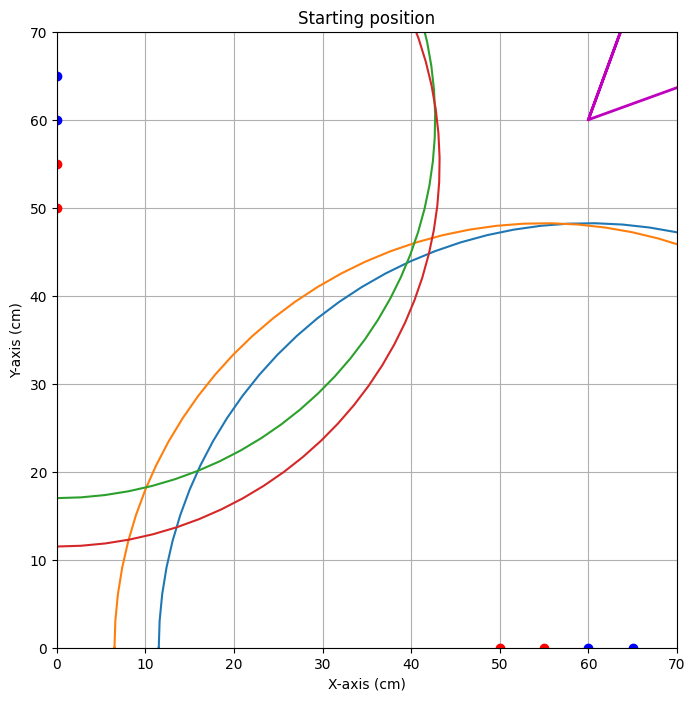


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=34.405


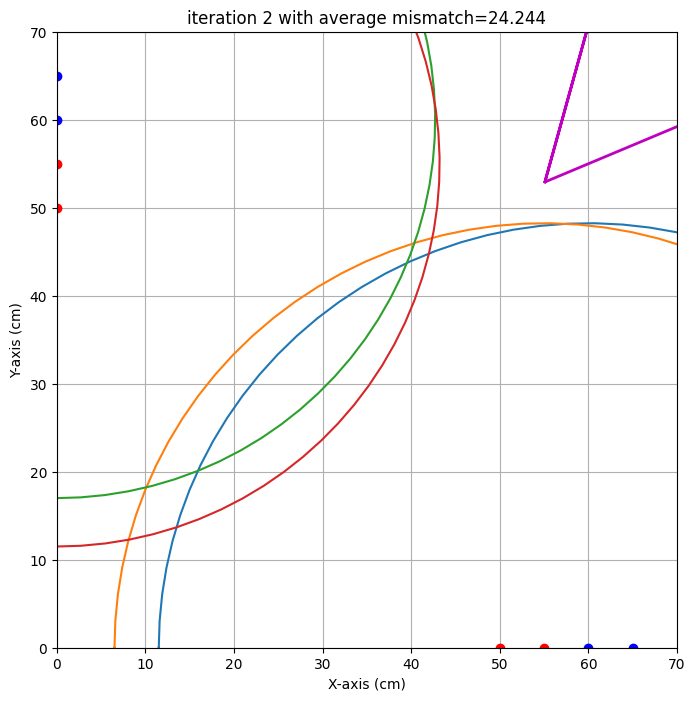

end iteration 2 with average mismatch=24.244


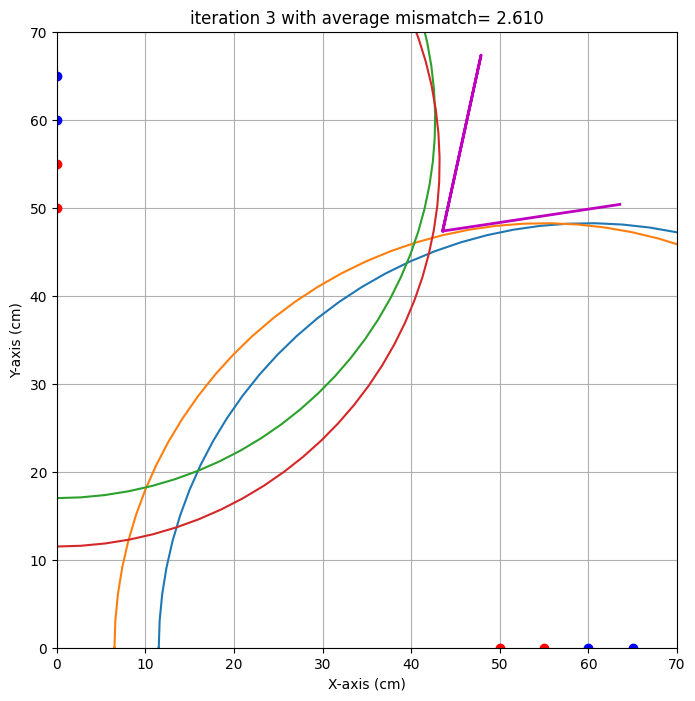

end iteration 3 with average mismatch= 2.610


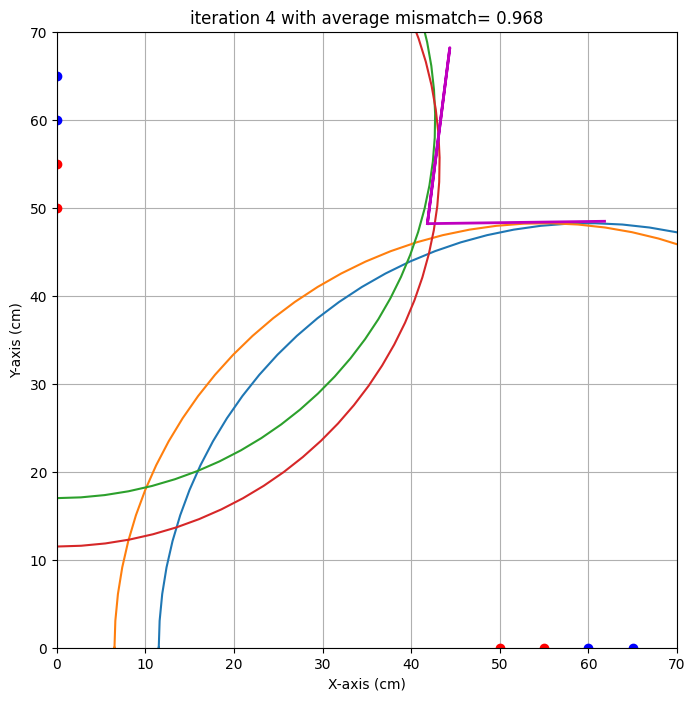

end iteration 4 with average mismatch= 0.968


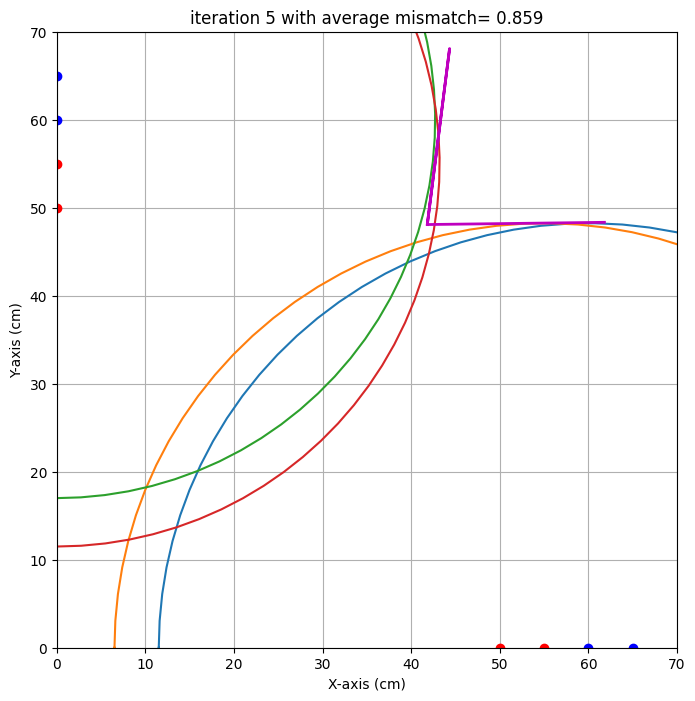

end iteration 5 with average mismatch= 0.859
end iteration 6 with average mismatch= 0.800
end iteration 7 with average mismatch= 0.743
end iteration 8 with average mismatch= 0.674


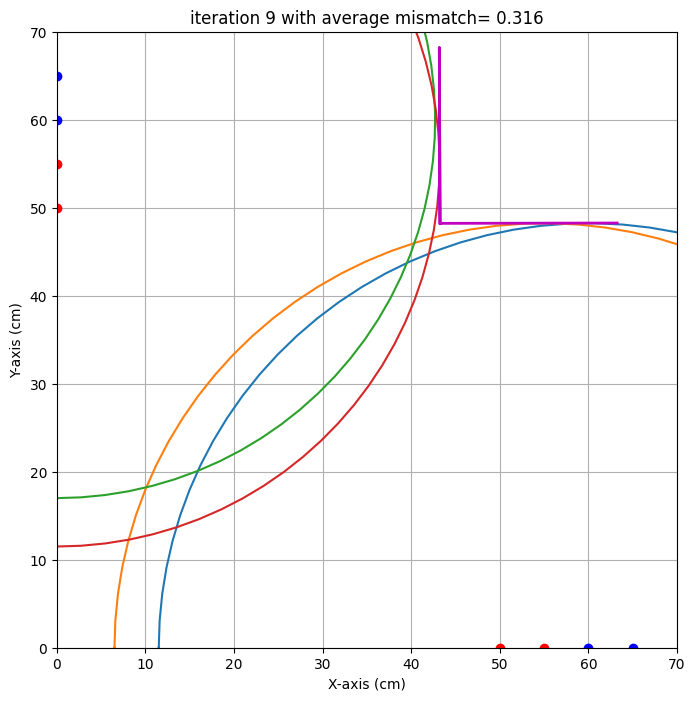

end iteration 9 with average mismatch= 0.316
end iteration 10 with average mismatch= 0.312
end iteration 11 with average mismatch= 0.311
end iteration 12 with average mismatch= 0.311
end iteration 13 with average mismatch= 0.311
end iteration 14 with average mismatch= 0.311
end iteration 15 with average mismatch= 0.311
end iteration 16 with average mismatch= 0.311
end iteration 17 with average mismatch= 0.311
end iteration 18 with average mismatch= 0.311
end iteration 19 with average mismatch= 0.311
end iteration 20 with average mismatch= 0.311
end iteration 21 with average mismatch= 0.311
end iteration 22 with average mismatch= 0.311
end iteration 23 with average mismatch= 0.311
end iteration 24 with average mismatch= 0.311
end iteration 25 with average mismatch= 0.311
end iteration 26 with average mismatch= 0.311
end iteration 27 with average mismatch= 0.311
end iteration 28 with average mismatch= 0.311
end iteration 29 with average mismatch= 0.311
Last iteration, also determine unce

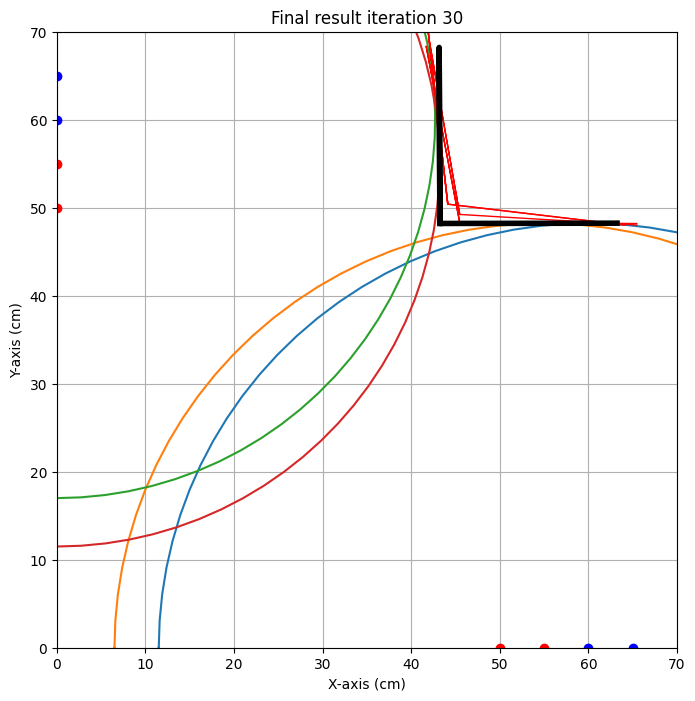

{'alpha': np.float64(0.09455308678659959), 'alpha_eps': np.float64(6.86957351556695), 'beta': np.float64(-0.23044851278504314), 'beta_eps': np.float64(10.482879803304087), 'x0': np.float64(43.23985227474441), 'x0_eps': np.float64(2.240071799771208), 'y0': np.float64(48.211092563953656), 'y0_eps': np.float64(2.1931725692994277)}


In [44]:
# Hier runnen we het imaging algoritme:
resultaat = dict()
studentNames = ["luuk", "Oscar", "Jochem"]

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [45]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

luuk 
x0 target is : 45.0. Gevonden waarde: 44.7 cm met een standaardafwijking van 0.6 cm 
y0 target is : 50.0. Gevonden waarde: 49.1 cm met een standaardafwijking van 1.7 cm 
alpha target is : -5.0. Gevonden waarde: -3.9 graden met een standaardafwijking van 10.2 graad 
beta target is : 5.0. Gevonden waarde: -10.8 graden met een standaardafwijking van 2.8 graad 

Oscar 
x0 target is : 45.0. Gevonden waarde: 42.6 cm met een standaardafwijking van 1.8 cm 
y0 target is : 50.0. Gevonden waarde: 50.1 cm met een standaardafwijking van 3.3 cm 
alpha target is : -5.0. Gevonden waarde: -5.7 graden met een standaardafwijking van 14.3 graad 
beta target is : 5.0. Gevonden waarde: 5.7 graden met een standaardafwijking van 9.0 graad 

Jochem 
x0 target is : 45.0. Gevonden waarde: 43.2 cm met een standaardafwijking van 2.2 cm 
y0 target is : 50.0. Gevonden waarde: 48.2 cm met een standaardafwijking van 2.2 cm 
alpha target is : -5.0. Gevonden waarde: 0.1 graden met een standaardafwijking van 6.9 gr

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](eindalgoritme.jpg)


In [46]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  30   0  20   0  55
1  35   0  20   0  56
2  40   0  20   0  58
3  45   0  20   0  60
4   0  30   0  20  56
5   0  35   0  20  57
6   0  40   0  20  58
7   0  45   0  20  62


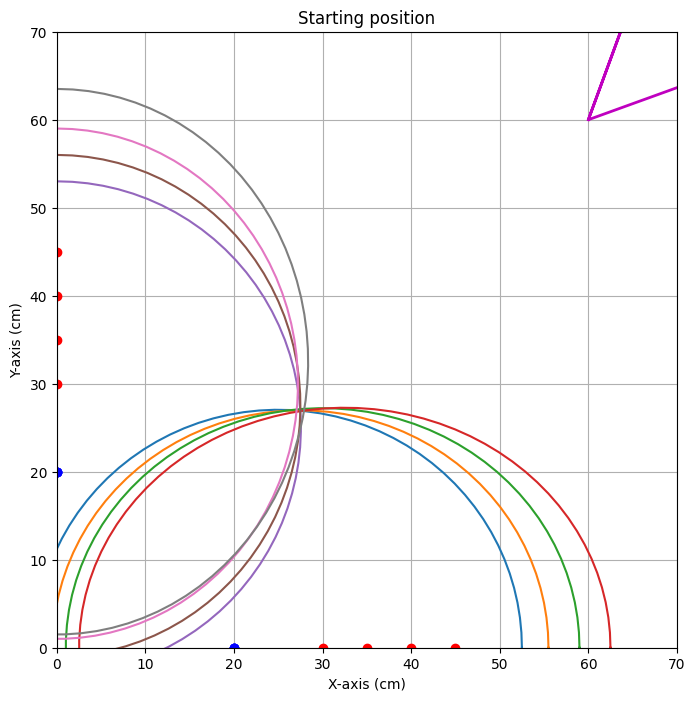


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=85.852


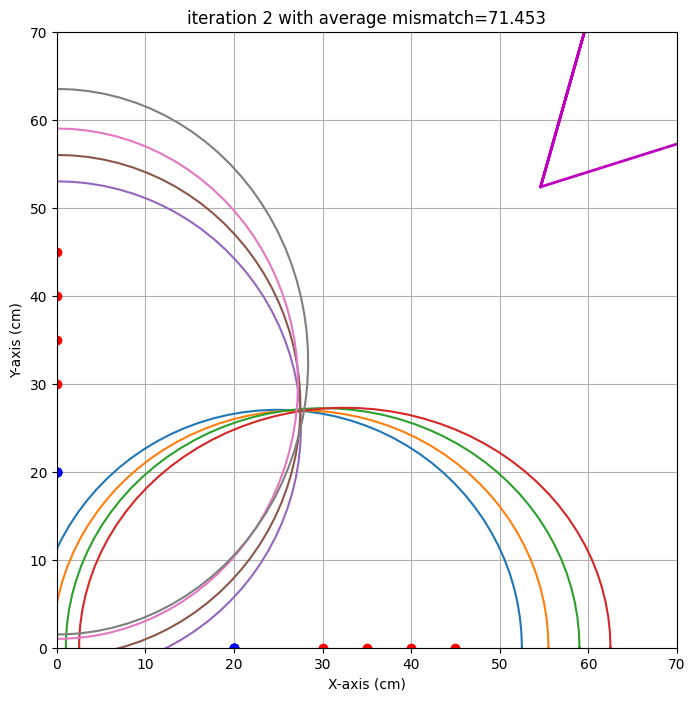

end iteration 2 with average mismatch=71.453


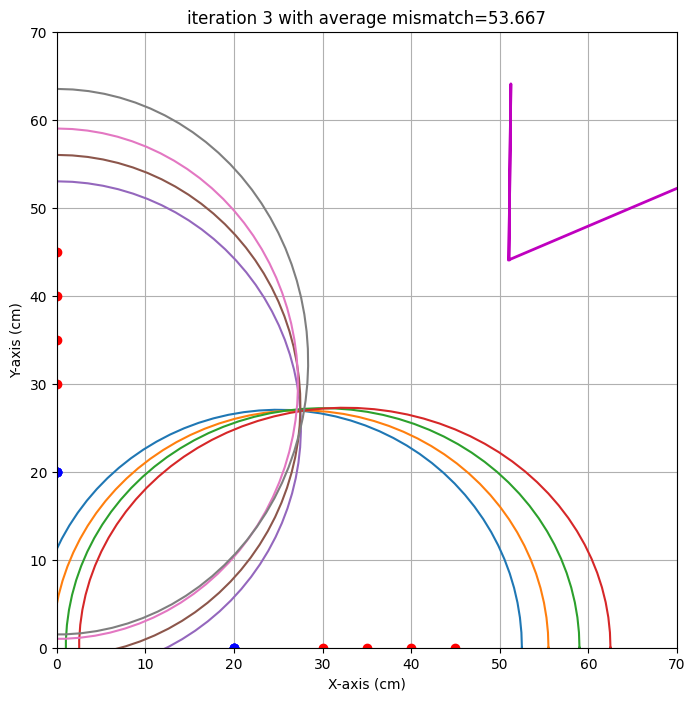

end iteration 3 with average mismatch=53.667


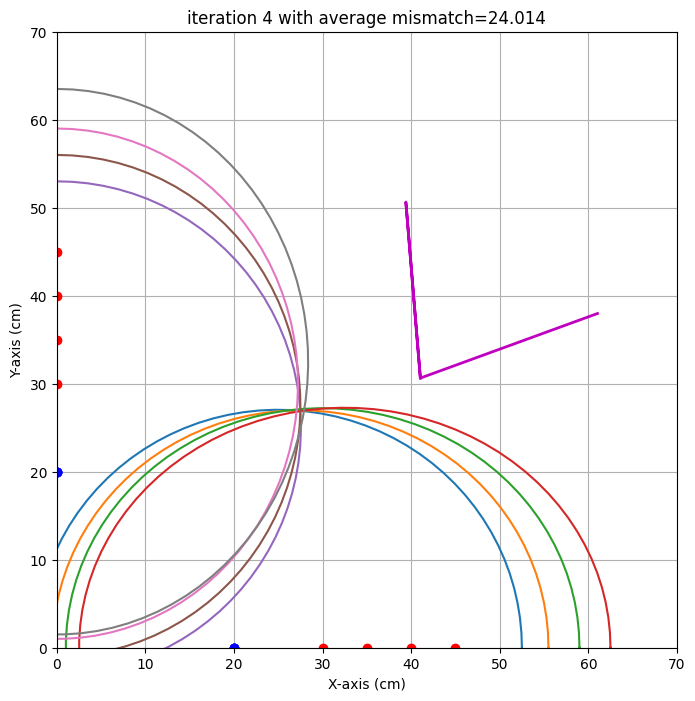

end iteration 4 with average mismatch=24.014


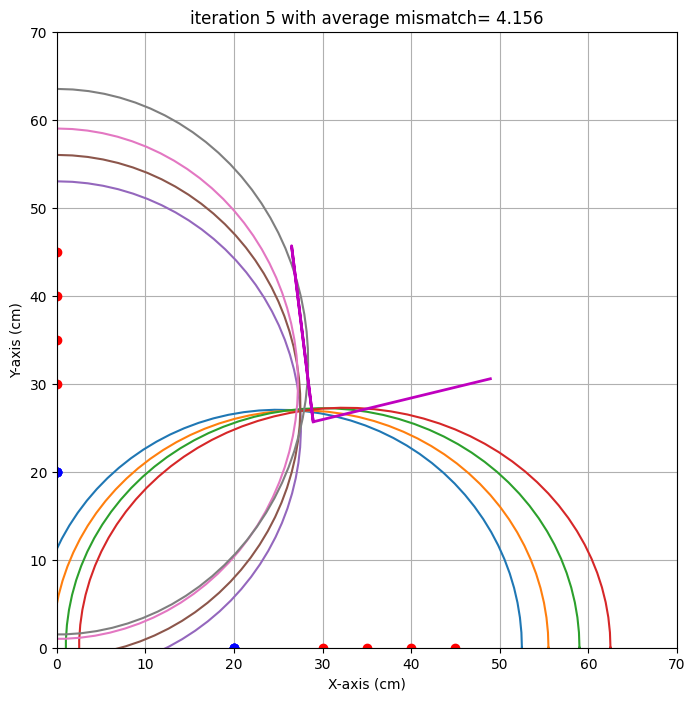

end iteration 5 with average mismatch= 4.156


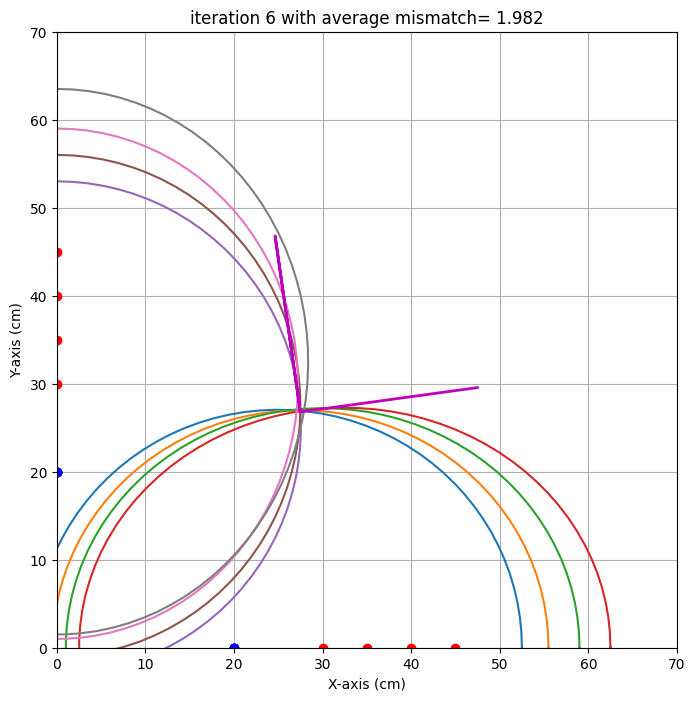

end iteration 6 with average mismatch= 1.982


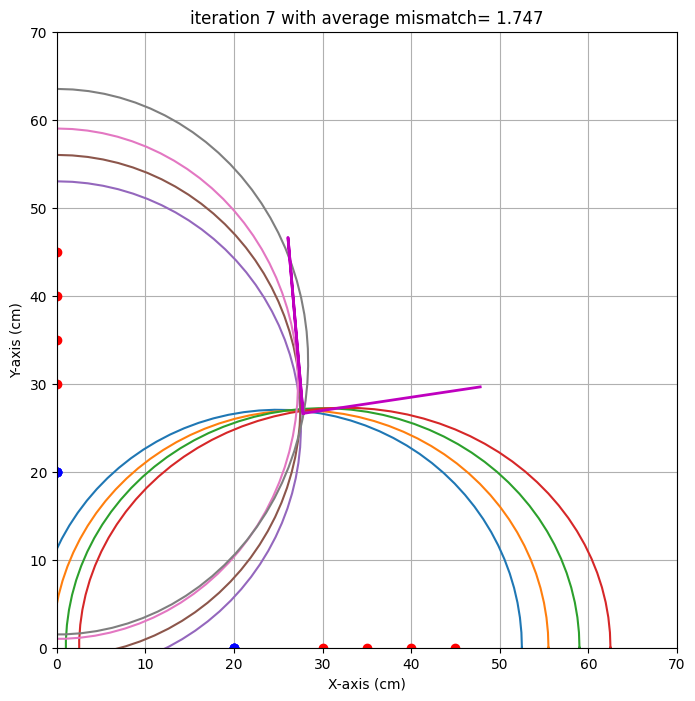

end iteration 7 with average mismatch= 1.747
end iteration 8 with average mismatch= 1.594
end iteration 9 with average mismatch= 1.593
end iteration 10 with average mismatch= 1.566
end iteration 11 with average mismatch= 1.443
end iteration 12 with average mismatch= 1.443
end iteration 13 with average mismatch= 1.415
end iteration 14 with average mismatch= 1.410


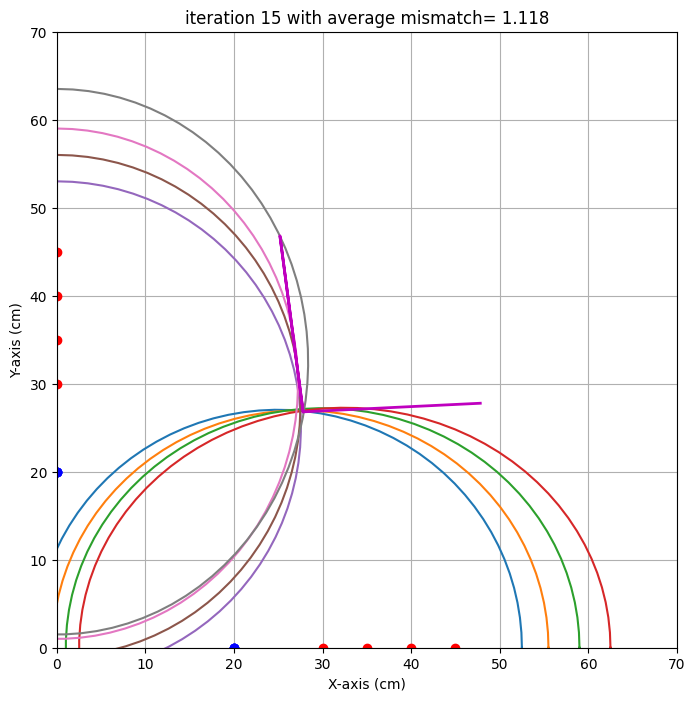

end iteration 15 with average mismatch= 1.118
end iteration 16 with average mismatch= 1.118
end iteration 17 with average mismatch= 1.118
end iteration 18 with average mismatch= 1.118
end iteration 19 with average mismatch= 1.118
end iteration 20 with average mismatch= 1.118
end iteration 21 with average mismatch= 1.113
end iteration 22 with average mismatch= 1.113
end iteration 23 with average mismatch= 1.077
end iteration 24 with average mismatch= 1.069
end iteration 25 with average mismatch= 1.063
end iteration 26 with average mismatch= 1.063
end iteration 27 with average mismatch= 1.063
end iteration 28 with average mismatch= 1.063
end iteration 29 with average mismatch= 1.063
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.063
###############################################################################
end of iteration  30
Best alpha=  -0.77 with uncertainty=   8.11
Best beta 

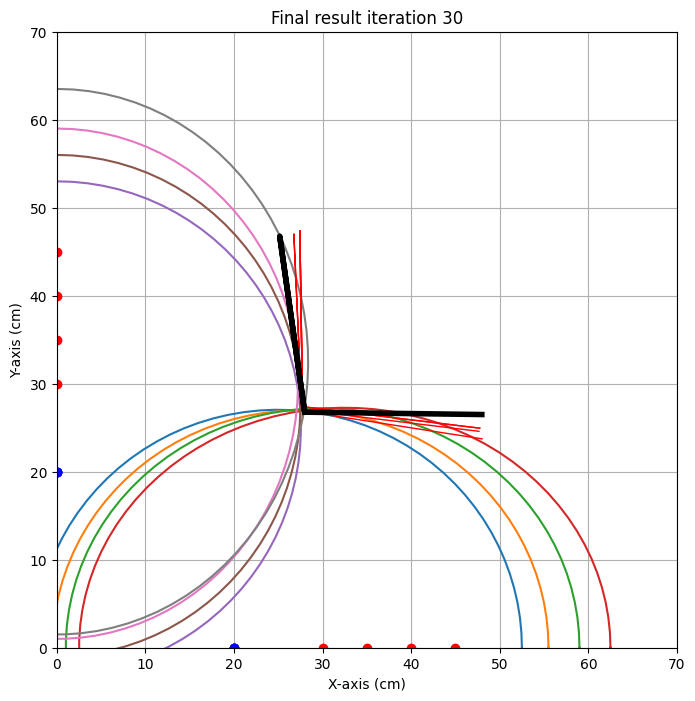

{'alpha': np.float64(-0.7726644961480538), 'alpha_eps': np.float64(8.113613502837005), 'beta': np.float64(-8.014709879066265), 'beta_eps': np.float64(7.137007796420364), 'x0': np.float64(27.973553957800963), 'x0_eps': np.float64(0.3265889699122795), 'y0': np.float64(26.768898126598565), 'y0_eps': np.float64(0.6230366613614606)}
locatie 1 
x0 target is : 28.0. Gevonden waarde: 28.0 cm met een standaardafwijking van 0.3 cm 
y0 target is : 25.0. Gevonden waarde: 26.8 cm met een standaardafwijking van 0.6 cm 
alpha target is : 3.0. Gevonden waarde: -0.8 graden met een standaardafwijking van 8.1 graad 
beta target is : -8.0. Gevonden waarde: -8.0 graden met een standaardafwijking van 7.1 graad 



In [47]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':28,#zelf aanvullen,
                    'y0':25,#zelf aanvullen,
                    'alpha' :3 ,#zelf aanvullen,
                    'beta' :-8 ,#zelf aanvullen},
           'locatie 2':{'x0': 43,#zelf aanvullen,
                    'y0':30,#zelf aanvullen,
                    'alpha' : 0,#zelf aanvullen,
                    'beta' : 0}
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,20,0,55],
    [35,0,20,0,56],
    [40,0,20,0,58],
    [45,0,20,0,60],
    [0,30,0,20,56],
    [0,35,0,20,57],
    [0,40,0,20,58],
    [0,45,0,20,62],
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    [40,0,30,0,68],
    [50,0,40,0,61],
    [55,0,40,0,62],
    [0,40,0,30,84],
    [0,45,0,30,85],
    [0,50,0,30,86],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  50   0  40   0  85
1  55   0  40   0  86
2  60   0  40   0  89
3  50   0  60   0  90
4   0  40   0  30  70
5   0  50   0  35  68
6   0  50   0  40  66


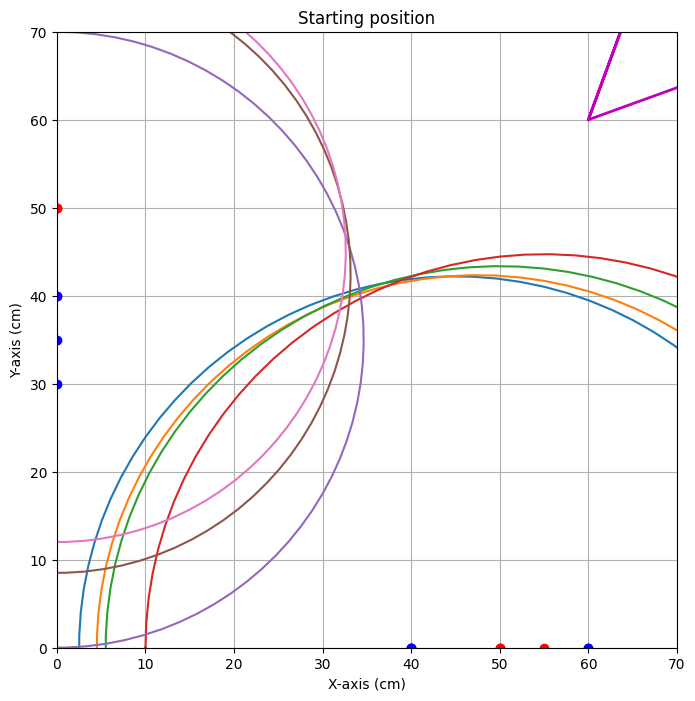


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.433


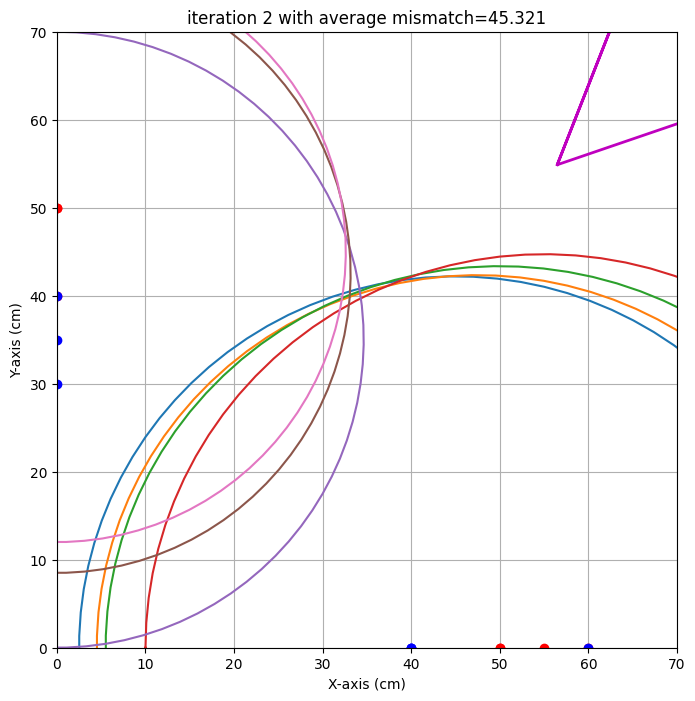

end iteration 2 with average mismatch=45.321


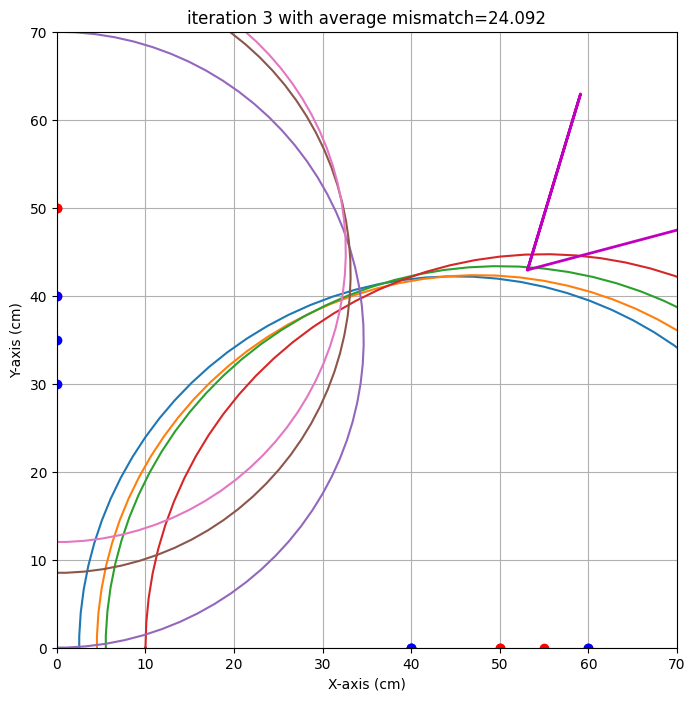

end iteration 3 with average mismatch=24.092


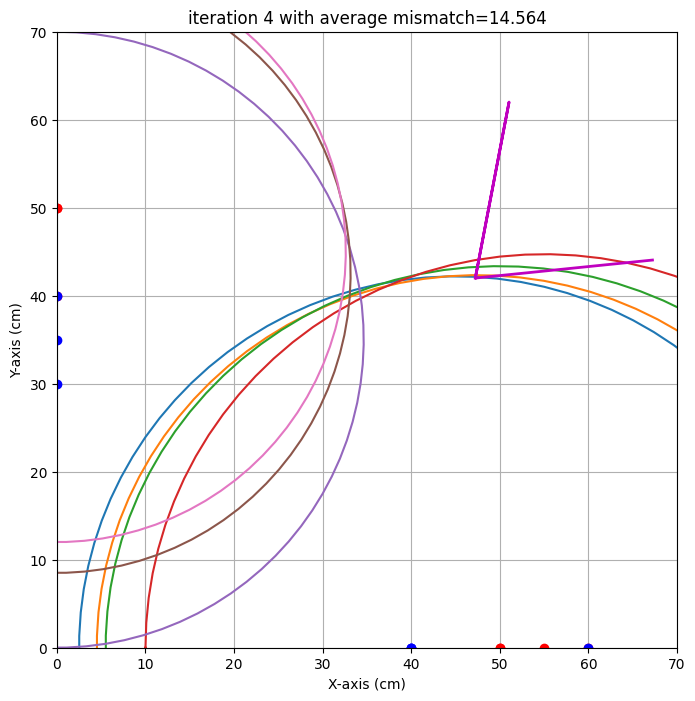

end iteration 4 with average mismatch=14.564


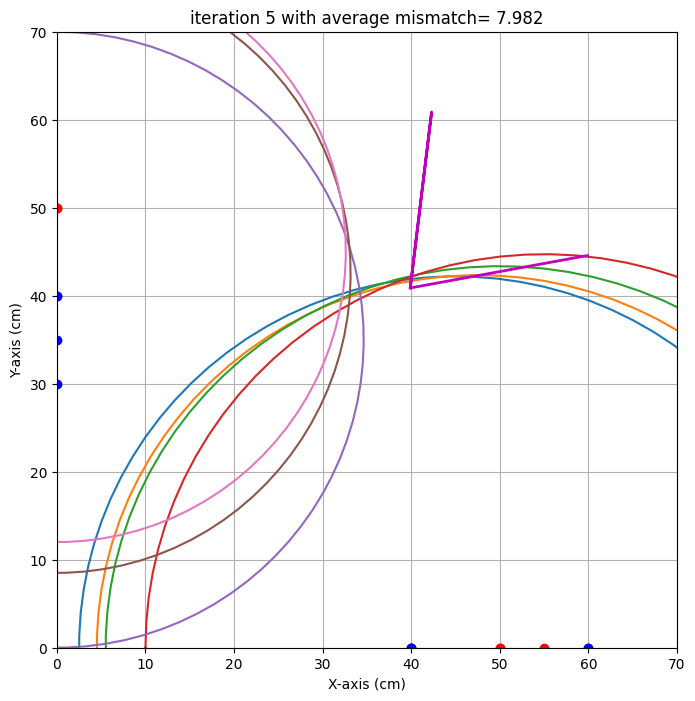

end iteration 5 with average mismatch= 7.982


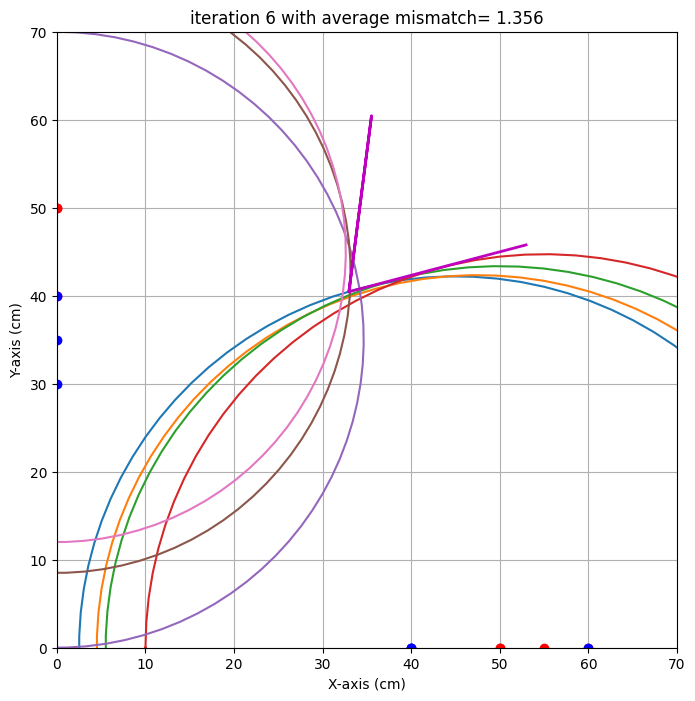

end iteration 6 with average mismatch= 1.356
end iteration 7 with average mismatch= 1.287


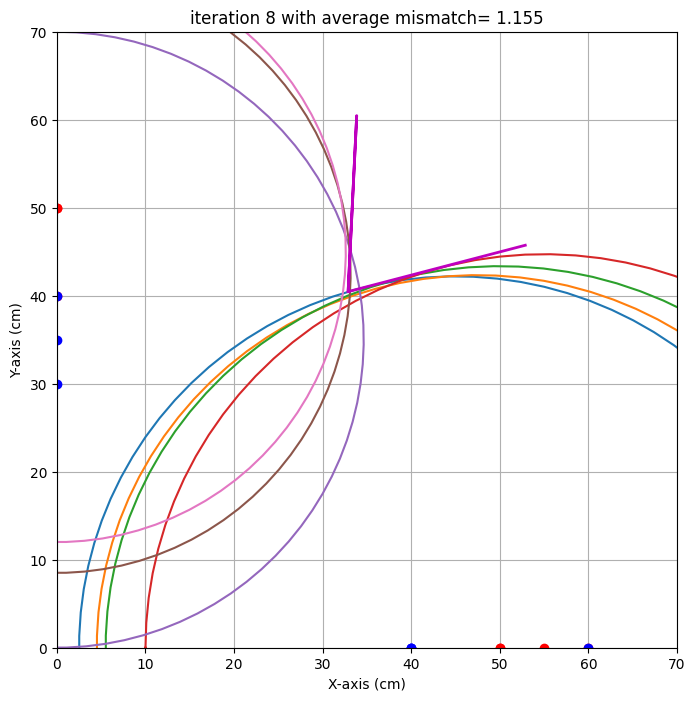

end iteration 8 with average mismatch= 1.155


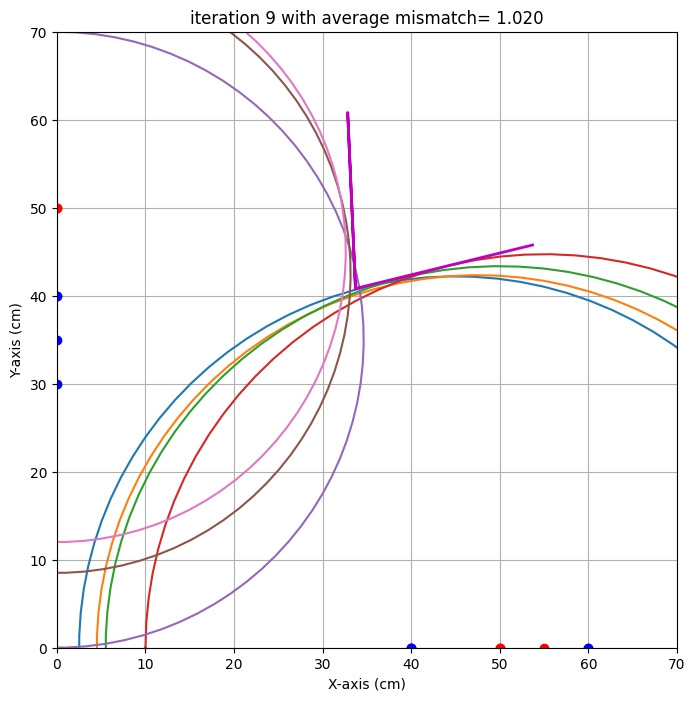

end iteration 9 with average mismatch= 1.020


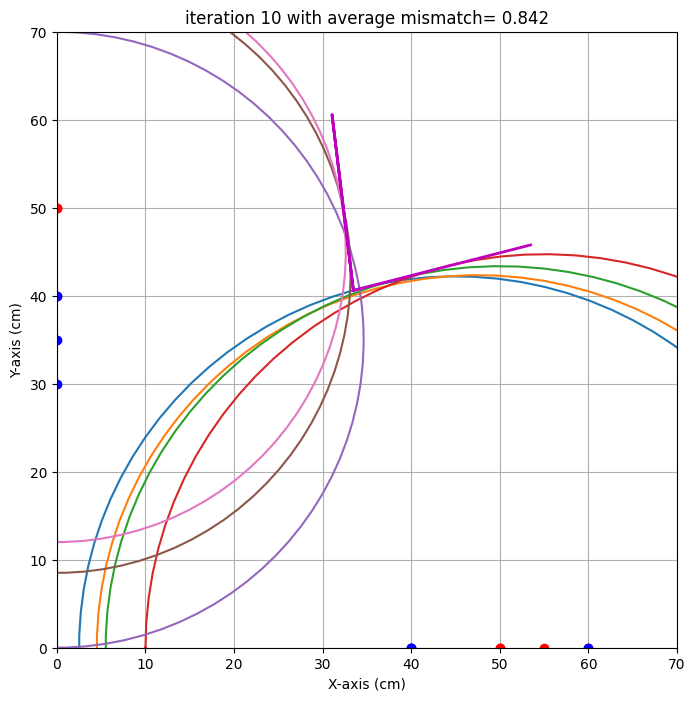

end iteration 10 with average mismatch= 0.842
end iteration 11 with average mismatch= 0.794


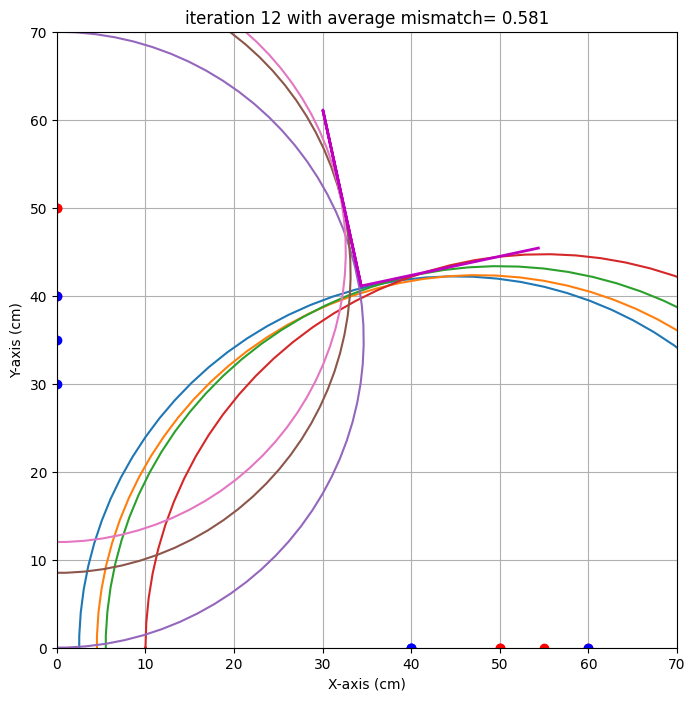

end iteration 12 with average mismatch= 0.581


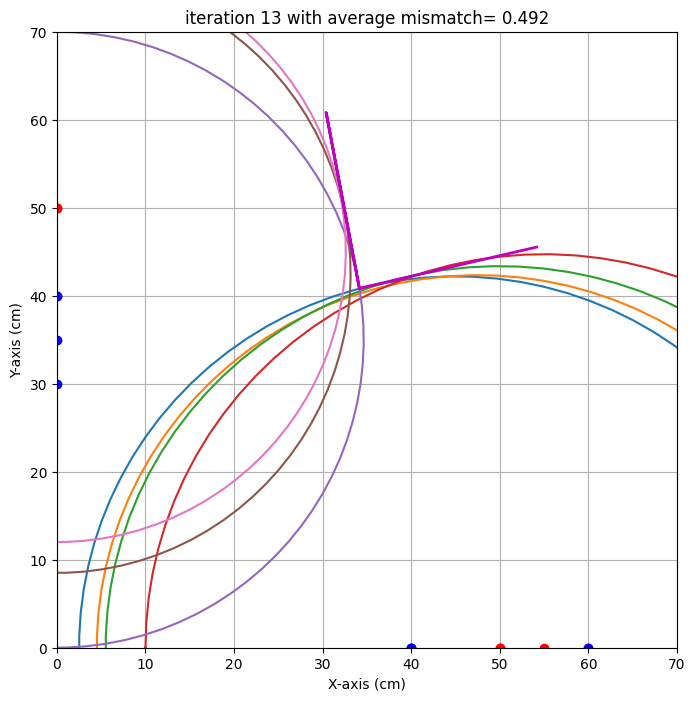

end iteration 13 with average mismatch= 0.492
end iteration 14 with average mismatch= 0.492
end iteration 15 with average mismatch= 0.453
end iteration 16 with average mismatch= 0.437
end iteration 17 with average mismatch= 0.396
end iteration 18 with average mismatch= 0.396
end iteration 19 with average mismatch= 0.395
end iteration 20 with average mismatch= 0.395
end iteration 21 with average mismatch= 0.395
end iteration 22 with average mismatch= 0.395
end iteration 23 with average mismatch= 0.395
end iteration 24 with average mismatch= 0.395
end iteration 25 with average mismatch= 0.395
end iteration 26 with average mismatch= 0.395
end iteration 27 with average mismatch= 0.395
end iteration 28 with average mismatch= 0.395
end iteration 29 with average mismatch= 0.395
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.395
###############################################################

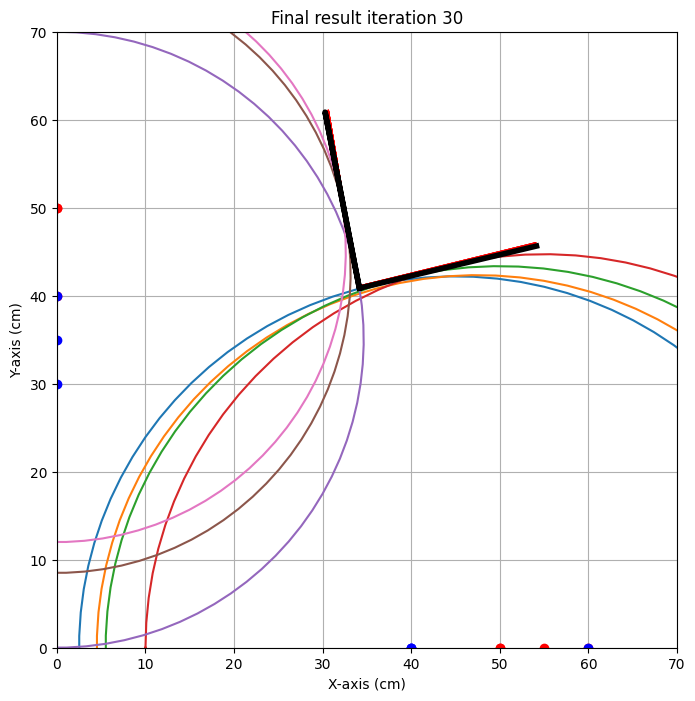

{'alpha': np.float64(13.458026973757041), 'alpha_eps': np.float64(0.3939584149553177), 'beta': np.float64(-10.952936406917884), 'beta_eps': np.float64(1.2828297805090791), 'x0': np.float64(34.147825180373175), 'x0_eps': np.float64(0.10116056235964521), 'y0': np.float64(40.859211862342235), 'y0_eps': np.float64(0.2176919538412676)}
test locatie 
x0 target is : 35.0. Gevonden waarde: 34.1 cm met een standaardafwijking van 0.1 cm 
y0 target is : 41.0. Gevonden waarde: 40.9 cm met een standaardafwijking van 0.2 cm 
alpha target is : 14.0. Gevonden waarde: 13.5 graden met een standaardafwijking van 0.4 graad 
beta target is : -11.0. Gevonden waarde: -11.0 graden met een standaardafwijking van 1.3 graad 



In [48]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 35, # zelf aanvullen,
                    'y0': 41, # zelf aanvullen,
                    'alpha':14,  # zelf aanvullen,
                    'beta':-11,   # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
#30,0,20,0,164  ,                  
#40,0,30,0,103, 
[50,0,40,0,85],
[55,0,40,0,86],
[60,0,40,0,89], 
[50,0,60,0,90], 
#0,30,0,20,1112   
[0,40,0,30,70],
#0,45,0,30,71 
#0,50,0,30,70
[0,50,0,35,68],  
[0,50,0,40,66],                ])             }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](algoritmeluuk.jpg "algoritme van Luuk")

Luuk:
Bij dit algoritme is slim gebruik gemaakt van de afstanden gegeven door de arduino, hierdoor scheelde dit een extra stap op de y-as. Dit werkte in de praktijk zoals verwacht. Op de x-as is gebruik gemaakt van gokken. Het resultaat was binnen de foutmarges.


Figuur: ![Alt](algoritmeoscar.jpg "algoritme van Oscar")

Oscar: Bij dit algoritme wordt ervoor gezorgd dat vanaf het moment dat er reële meting komen de reciever steeds verder komt dan de transmitter zodat er een goede spreiding van metingen komt. Ditr gebeurt bij beide assen waardoor er uiteindelijk een goede sprieding komt van grotere en kleinere afstanden. Deze is ook uiteindelijk gekozen omdat deze het nauwkeurigst bleek.

Figuur: ![Alt](algoritmejochem.jpg "algoritme van Jochem")

Jochem:
Bij dit algoritme is gebruik gemaakt van kansen, door te kijken of het karton niet toevallig op de lijn tussen de sensoren ligt, of links en rechts van de lijn. Hoeveel metingen je moet doen hangt dus af van welke kant van de lijn je kiest om te gaan meten na de eerste meting. In ons geval hebben we de goede kant gekozen en hierbij een resultaat behaald binnen de marges. Dus we hebben ook bij dit algoritme een geslaagd resultaat.